# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset berasal dari kaggle yang bisa diakses melalui link https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data. Data ini merupakan Sistem Survei Faktor Risiko Perilaku (Behavioral Risk Factor Surveillance System/BRFSS) adalah survei kesehatan melalui telepon yang dikumpulkan setiap tahun oleh CDC (Centers for Disease Control and Prevention). Setiap tahunnya, survei ini mengumpulkan respons dari lebih dari 400.000 warga Amerika terkait perilaku berisiko terhadap kesehatan, kondisi kesehatan kronis, dan penggunaan layanan pencegahan. Survei ini telah dilakukan sejak tahun 1984. Dalam proyek ini, digunakan dataset dalam format CSV dari tahun 2015 yang tersedia di Kaggle. Dataset ini berisi respons dari 253,680 individu dan memiliki 22 fitur. Fitur-fitur ini merupakan pertanyaan yang diajukan langsung kepada peserta, atau variabel yang dihitung berdasarkan respons masing-masing peserta.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [56]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [113]:
# Load Data
df = pd.read_csv("/content/diabetes_raw.csv")
print('Ukuran dataset: ', df.shape)
df.head()

Ukuran dataset:  (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Dataset ini terdiri dari 253.680 baris data dan 22 atribut. Berikut adalah penjelasan untuk setiap kolom:

- Diabetes_binary: 0 = tidak menderita diabetes, 1 = menderita diabetes.
- HighBP: 0 = tidak memiliki tekanan darah tinggi, 1 = memiliki tekanan darah tinggi.
- HighChol: 0 = tidak memiliki kolesterol tinggi, 1 = memiliki kolesterol tinggi.
- CholCheck: 0 = tidak pernah melakukan pemeriksaan kolesterol dalam 5 tahun terakhir, 1 = pernah melakukan pemeriksaan kolesterol dalam 5 tahun terakhir.
- BMI: Indeks Massa Tubuh (Body Mass Index).
- Smoker: Apakah pernah merokok setidaknya 100 batang rokok seumur hidup? [Catatan: 5 bungkus = 100 batang rokok] 0 = tidak, 1 = ya.
- Stroke: Pernahkah diberitahu bahwa Anda mengalami stroke? 0 = tidak, 1 = ya.
- HeartDiseaseorAttack: Pernah mengalami penyakit jantung koroner (CHD) atau serangan jantung (MI). 0 = tidak, 1 = ya.
- PhysActivity: Aktivitas fisik dalam 30 hari terakhir (tidak termasuk aktivitas kerja). 0 = tidak, 1 = ya.
- Fruits: Mengonsumsi buah satu kali atau lebih per hari. 0 = tidak, 1 = ya.
- Veggies: Mengonsumsi sayuran satu kali atau lebih per hari. 0 = tidak, 1 = ya.
- HvyAlcoholConsump: Konsumsi alkohol berat (pria dewasa ≥14 minuman per minggu, wanita dewasa ≥7 minuman per minggu). 0 = tidak, 1 = ya.
- AnyHealthcare: Memiliki jenis perlindungan kesehatan apa pun, termasuk asuransi kesehatan, paket prabayar seperti HMO, dll. 0 = tidak, 1 = ya.
- NoDocbcCost: Dalam 12 bulan terakhir, pernahkah Anda membutuhkan dokter tetapi tidak bisa karena biaya? 0 = tidak, 1 = ya.
- GenHlth: Penilaian kesehatan secara umum: skala 1-5 (1 = sangat baik, 2 = baik, 3 = cukup, 4 = kurang, 5 = buruk).
- MentHlth: Jumlah hari dengan kesehatan mental buruk dalam 30 hari terakhir (skala 1-30 hari).
- PhysHlth: Jumlah hari dengan sakit fisik atau cedera dalam 30 hari terakhir (skala 1-30 hari).
- DiffWalk: Apakah mengalami kesulitan serius berjalan atau menaiki tangga? 0 = tidak, 1 = ya.
- Sex: 0 = perempuan, 1 = laki-laki.
- Age: Kategori umur dalam 13 level, dimulai dari 1 = 18-24 tahun hingga 13 = 80 tahun ke atas (inkremen 5 tahun).
- Education: Tingkat pendidikan (mengacu pada kode EDUCA): skala 1-6 (1 = tidak pernah sekolah atau hanya taman kanak-kanak, 6 = perguruan tinggi 4 tahun atau lebih).
- Income: Skala pendapatan (mengacu pada kode INCOME2): skala 1-8 (1 = kurang dari 10.000 hingga 8 = 75.000 atau lebih) dalam dollar.

In [4]:
# Cek data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Dataset ini terdiri dari 253.680 entri tanpa nilai kosong dan memiliki 22 kolom dengan tipe data numerik (float64). Seluruh kolom merepresentasikan variabel kategori biner atau ordinal, serta beberapa variabel numerik kontinu seperti BMI, jumlah hari kesehatan mental/fisik terganggu, dan tingkat kesehatan secara umum.

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# cek duplicate
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 24206


Terdapat 24.206 data duplikat yang sebaiknya dihapus untuk memastikan analisis yang akurat.

In [7]:
# cek missing value
print("Cek missing value:")
print(df.isnull().sum())

Cek missing value:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Dataset ini tidak memiliki nilai yang hilang (missing values), sehingga tidak memerlukan penanganan khusus terkait data yang tidak lengkap.

In [9]:
# Kolom numerik
num_col = [
    'BMI', 'GenHlth', 'MentHlth', 'PhysHlth',
    'Age', 'Education', 'Income'
]

# Kolom kategorik
cat_col = [
    'Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck',
    'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

In [10]:
# Statistik dasar
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
GenHlth,253680.0,2.511392,1.068477,1.0,2.0,2.0,3.0,5.0
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
Age,253680.0,8.032119,3.054220,1.0,6.0,8.0,10.0,13.0
Education,253680.0,5.050434,0.985774,1.0,4.0,5.0,6.0,6.0
Income,253680.0,6.053875,2.071148,1.0,5.0,7.0,8.0,8.0


Berdasarkan statistik deskriptif untuk kolom numerik:

- BMI memiliki nilai rata-rata sekitar 28,4 dengan rentang 12 hingga 98, menunjukkan variasi yang signifikan dalam indeks massa tubuh peserta.
- GenHlth (tingkat kesehatan secara umum) sebagian besar berada pada skala 1-3 (baik hingga sangat baik), dengan rata-rata 2,5.
- MentHlth (jumlah hari kesehatan mental terganggu) rata-rata 3,18, dengan rentang dari 0 hingga 30, menunjukkan bahwa sebagian besar peserta memiliki sedikit gangguan kesehatan mental.
- PhysHlth (jumlah hari kesehatan fisik terganggu) rata-rata 4,24, dengan variasi dari 0 hingga 30.
- Age memiliki rata-rata kategori umur 8 (sekitar 45–54 tahun), dengan kategori umur tertua (13) mewakili usia 80 tahun ke atas.
- Education sebagian besar berada di kategori 5 dan 6, yang berarti kebanyakan peserta memiliki pendidikan lebih dari SMA hingga sarjana.
- Income menunjukkan bahwa sebagian besar peserta berada pada kategori pendapatan menengah hingga tinggi, dengan rata-rata di kategori 6 (sekitar 35,000-49,999) hingga 8 (lebih dari $75,000).

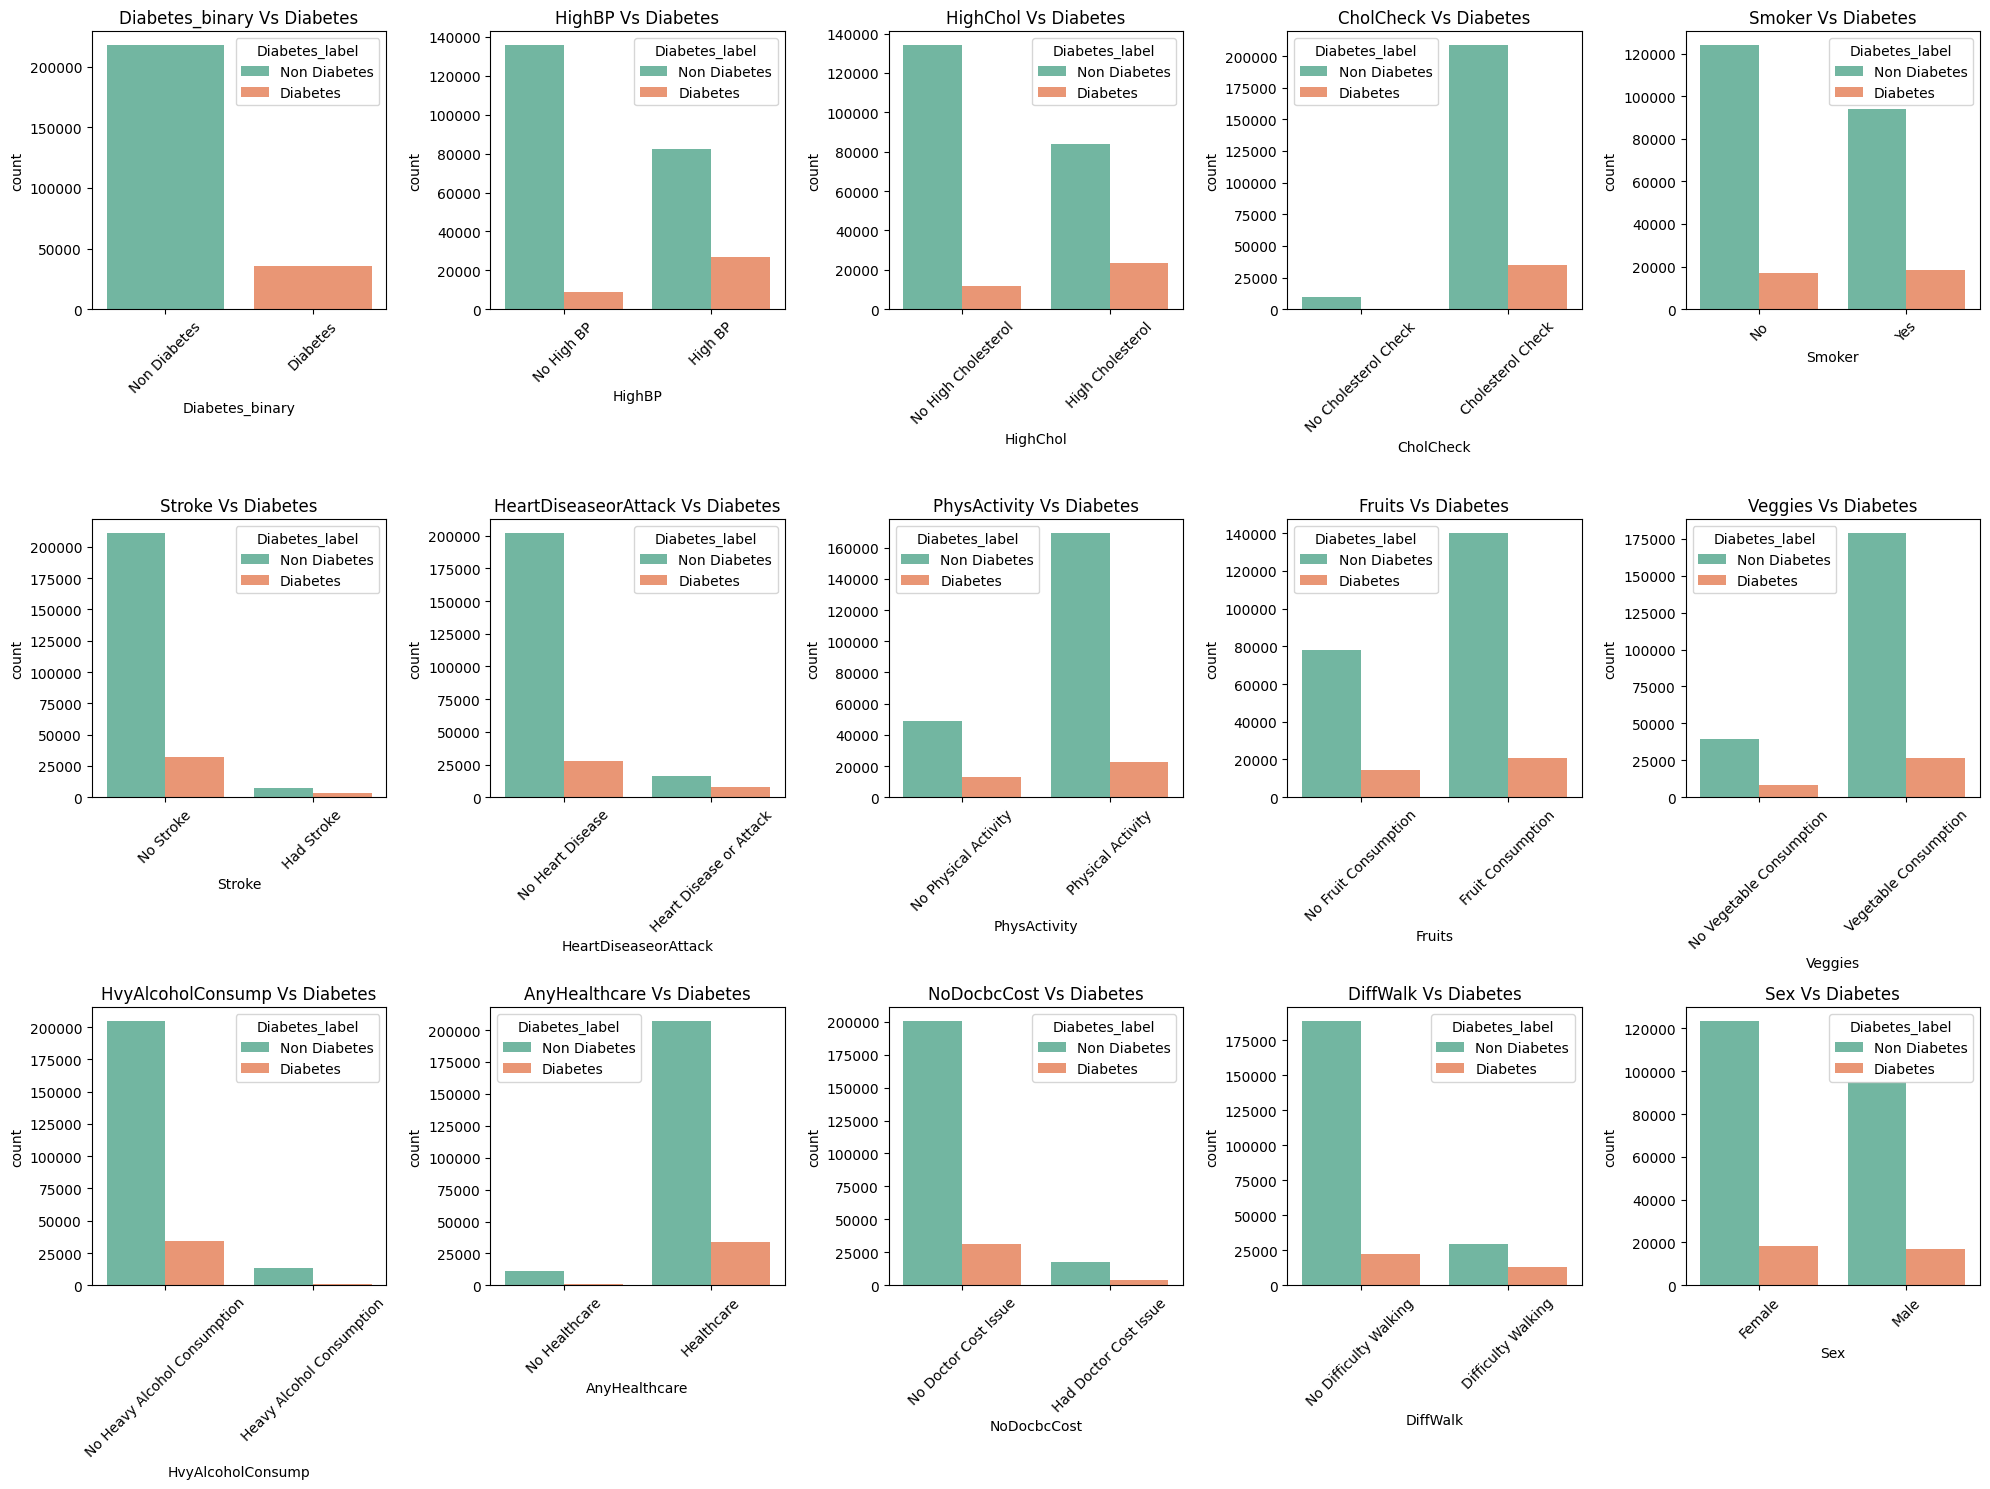

In [21]:
# Label untuk setiap variabel kategorik
labels = {
    'Diabetes_binary': ['Non Diabetes', 'Diabetes'],
    'HighBP': ['No High BP', 'High BP'],
    'HighChol': ['No High Cholesterol', 'High Cholesterol'],
    'CholCheck': ['No Cholesterol Check', 'Cholesterol Check'],
    'Smoker': ['No', 'Yes'],
    'Stroke': ['No Stroke', 'Had Stroke'],
    'HeartDiseaseorAttack': ['No Heart Disease', 'Heart Disease or Attack'],
    'PhysActivity': ['No Physical Activity', 'Physical Activity'],
    'Fruits': ['No Fruit Consumption', 'Fruit Consumption'],
    'Veggies': ['No Vegetable Consumption', 'Vegetable Consumption'],
    'HvyAlcoholConsump': ['No Heavy Alcohol Consumption', 'Heavy Alcohol Consumption'],
    'AnyHealthcare': ['No Healthcare', 'Healthcare'],
    'NoDocbcCost': ['No Doctor Cost Issue', 'Had Doctor Cost Issue'],
    'DiffWalk': ['No Difficulty Walking', 'Difficulty Walking'],
    'Sex': ['Female', 'Male']
}

# Mapping label diabetes
df['Diabetes_label'] = df['Diabetes_binary'].map({0: 'Non Diabetes', 1: 'Diabetes'})

# Menentukan jumlah baris dan kolom subplot
n_rows = 3
n_cols = 5

# Membuat subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()  # Meratakan grid subplot

# Visualisasi countplot untuk setiap variabel kategorik dalam subplot
for i, col in enumerate(cat_col):
    sns.countplot(data=df, x=col, ax=axes[i], hue='Diabetes_label', palette='Set2')
    axes[i].set_title(f'{col} Vs Diabetes')
    axes[i].set_xticks([0, 1])  # Menyesuaikan ticks
    axes[i].set_xticklabels(labels[col])  # Menambahkan label
    axes[i].tick_params(axis='x', rotation=45)

# Menyesuaikan layout agar tidak tumpang tindih
plt.tight_layout()
plt.show()

Berdasarkan grafik di atas, terlihat bahwa individu dengan diabetes cenderung mengalami masalah kesehatan lebih sering dibandingkan dengan individu non diabetes. Sebagai contoh, lebih banyak individu dengan diabetes yang memiliki kondisi seperti tekanan darah tinggi dan kolesterol tinggi, yang menunjukkan adanya hubungan antara diabetes dan masalah kardiovaskular. Selain itu, pemeriksaan kolesterol lebih sering dilakukan oleh individu dengan diabetes, yang bisa jadi mencerminkan upaya pemantauan kesehatan yang lebih intensif bagi penderita diabetes. Di sisi lain, aktivitas fisik lebih tinggi di kalangan individu non diabetes, yang mungkin menunjukkan bahwa mereka lebih aktif menjaga kesehatan tubuh mereka, sementara individu dengan diabetes mungkin menghadapi hambatan dalam berolahraga. Konsumsi buah dan sayuran juga lebih tinggi di kalangan individu non diabetes, mengindikasikan bahwa pola makan yang sehat lebih umum di kalangan mereka yang tidak menderita diabetes. Di sisi lain, individu dengan diabetes lebih sering mengalami kesulitan berjalan dan memiliki lebih banyak masalah terkait biaya perawatan kesehatan, yang mengindikasikan bahwa diabetes dapat membatasi mobilitas dan akses terhadap layanan kesehatan.

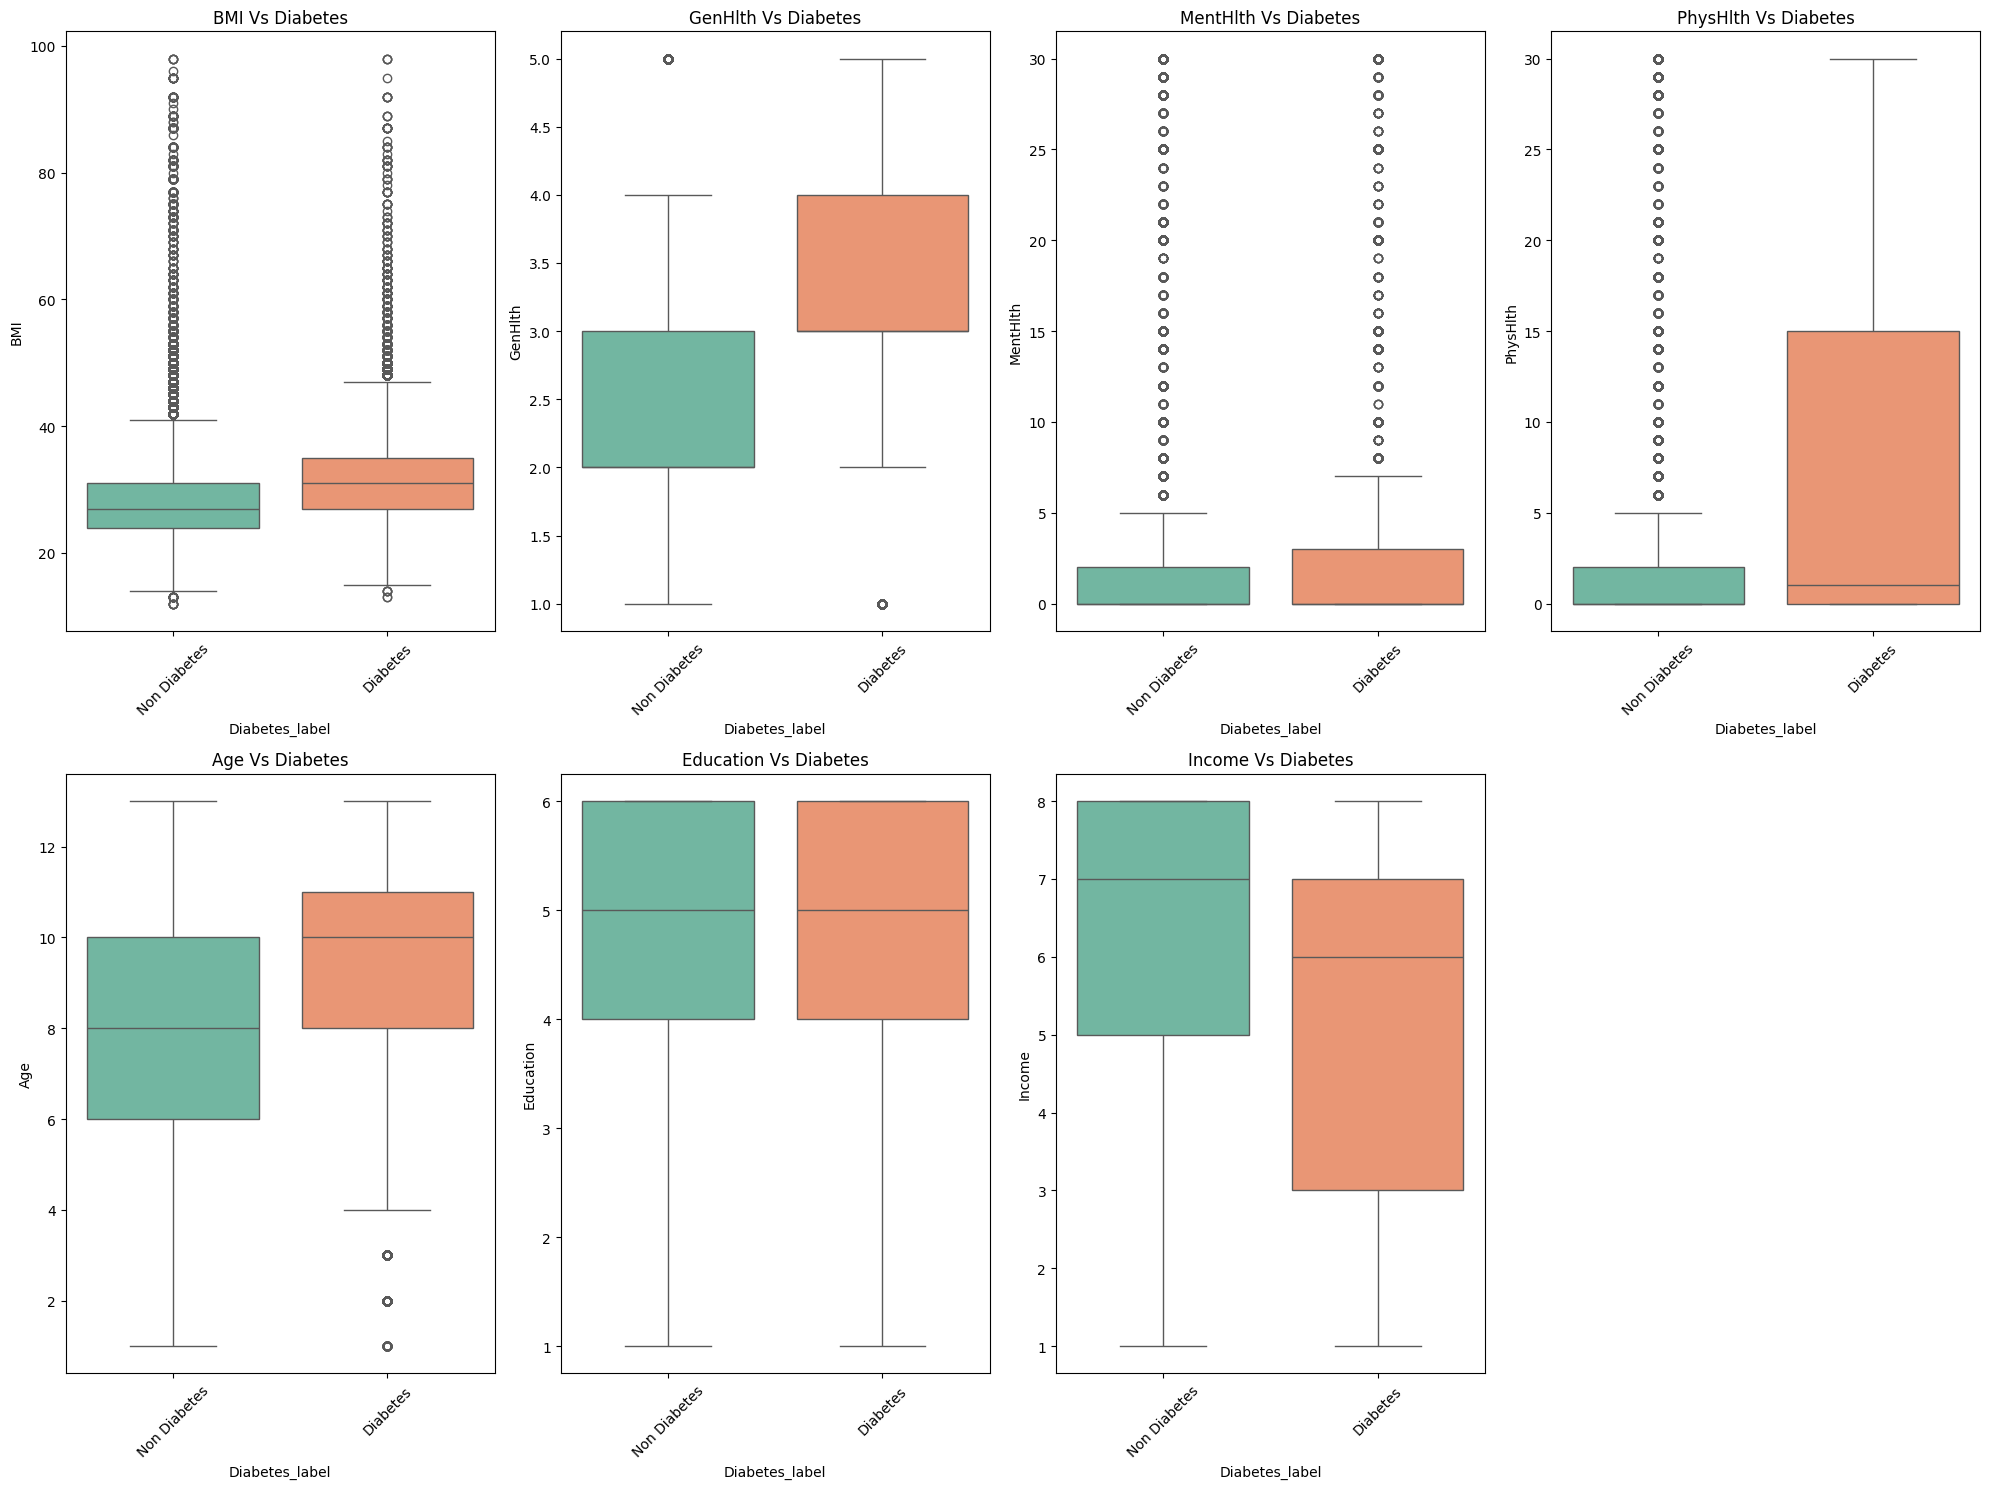

In [23]:
# Menentukan jumlah baris dan kolom subplot
n_rows = 2
n_cols = 4

# Membuat subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()  # Meratakan grid subplot

# Visualisasi boxplot untuk setiap variabel numerik dalam subplot
for i, col in enumerate(num_col):
    sns.boxplot(data=df, x='Diabetes_label', y=col, ax=axes[i], palette='Set2')  # Menyesuaikan x dan y
    axes[i].set_title(f'{col} Vs Diabetes')
    axes[i].tick_params(axis='x', rotation=45)

# Jika ada subplot yang kosong (lebih banyak subplot daripada kolom), matikan tampilannya
for j in range(len(num_col), len(axes)):
    axes[j].axis('off')

# Menyesuaikan layout agar tidak tumpang tindih
plt.tight_layout()
plt.show()

Boxplot menunjukkan bahwa penderita diabetes cenderung memiliki BMI lebih tinggi, kesehatan fisik dan mental lebih buruk, serta usia lebih tua dibandingkan non-diabetes. Distribusi pendidikan dan pendapatan lebih rendah pada kelompok diabetes mengindikasikan pengaruh faktor sosial ekonomi. Rentang antar kuartil yang lebih lebar serta outlier yang signifikan pada kesehatan fisik dan mental menunjukkan variasi kondisi yang besar dalam kelompok ini, mempertegas bahwa diabetes tidak hanya dipengaruhi oleh faktor biologis, tetapi juga gaya hidup dan kondisi sosial ekonomi.

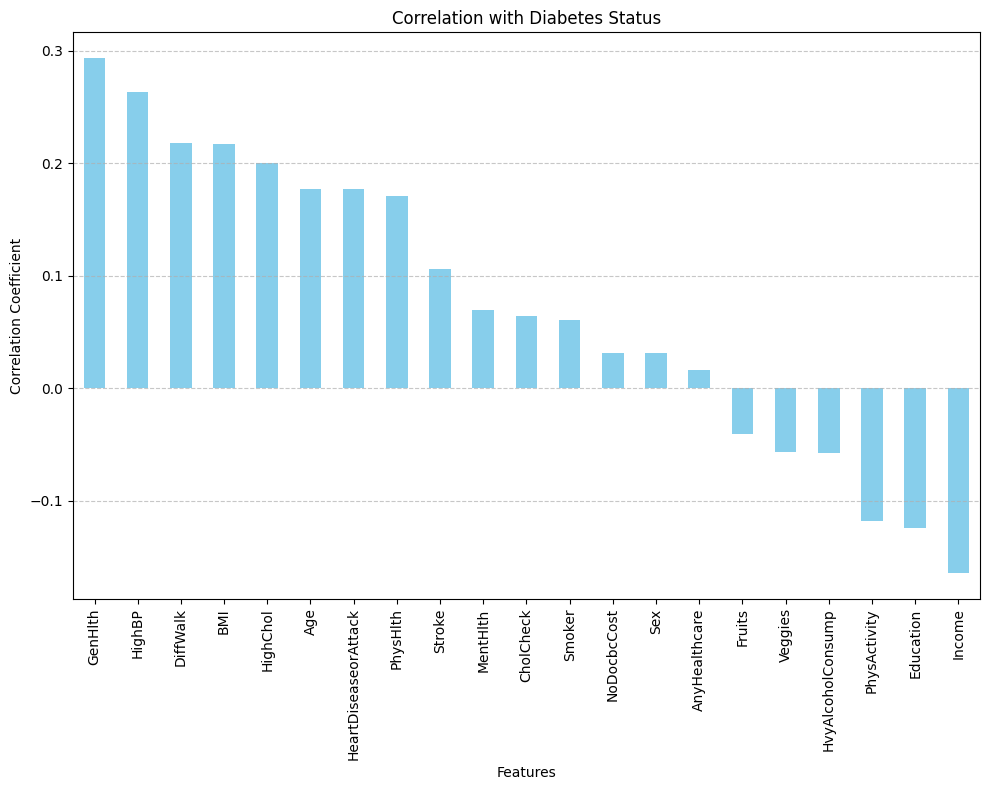

In [24]:
# Korelasi
correlation_with_target = df.corr(numeric_only=True)['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
plt.figure(figsize=(10, 8))
correlation_with_target.plot(kind='bar', color='skyblue')
plt.title('Correlation with Diabetes Status')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Korelasi menunjukkan bahwa faktor kesehatan seperti GenHlth (0.29), HighBP (0.26), dan DiffWalk (0.22) memiliki hubungan positif yang signifikan dengan diabetes. Sementara itu, Income (-0.16) dan Education (-0.12) memiliki korelasi negatif, menunjukkan bahwa individu dengan pendapatan atau pendidikan lebih tinggi cenderung memiliki risiko diabetes lebih rendah. Faktor gaya hidup seperti Fruits (-0.04) dan Veggies (-0.06) menunjukkan korelasi negatif lemah dengan diabetes.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [57]:
# drop duplicate
df = df.drop_duplicates()
print('Ukuran dataset: ', df.shape)

Ukuran dataset:  (229474, 23)


In [60]:
# Pisahkan fitur numerik dan kategorikal
# Kolom numerik
num_col = [
    'BMI', 'GenHlth', 'MentHlth', 'PhysHlth',
    'Age', 'Education', 'Income'
]

# Kolom kategorik
cat_col = [
    'Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck',
    'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

# Imputer median untuk numerik
imputer_num = SimpleImputer(strategy='median')
df[num_col] = imputer_num.fit_transform(df[num_col])

# Imputer modus (most frequent) untuk kategorikal
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_col] = imputer_cat.fit_transform(df[cat_col])

In [61]:
# Buat mask untuk menandai baris yang tidak outlier
mask = pd.Series(True, index=df.index)

# Iterasi setiap fitur numerik
for feature in num_col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= (df[feature] >= lower_bound) & (df[feature] <= upper_bound)

# Terapkan mask ke df langsung
df = df[mask].reset_index(drop=True)

In [62]:
# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['Diabetes_label', 'Diabetes_binary'])
y = df['Diabetes_binary']

In [63]:
# Skala fitur numerik menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
# Menyplit data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [110]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from joblib import dump, load
from imblearn.over_sampling import SMOTE

def preprocess_data(input_path, target_column, save_path, file_path, output_path):
    # Baca data
    df = pd.read_csv(input_path)
    print(f"Data berhasil dibaca dari: {input_path}")

    # Kolom numerik dan kategorikal
    num_col = [
        'BMI', 'GenHlth', 'MentHlth', 'PhysHlth',
        'Age', 'Education', 'Income'
    ]

    cat_col = [
        'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
        'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
        'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
        'DiffWalk', 'Sex'
    ]

    # Simpan nama kolom (tanpa target) ke file CSV
    df.drop(columns=[target_column]).head(0).to_csv(file_path, index=False)
    print(f"Nama kolom berhasil disimpan ke: {file_path}")

    # Hapus duplikat & baris dengan NA pada target
    df = df.drop_duplicates()
    df = df.dropna(subset=[target_column])

    # Outlier removal (IQR)
    mask = pd.Series(True, index=df.index)
    for feature in num_col:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (df[feature] >= lower) & (df[feature] <= upper)
    df = df[mask].reset_index(drop=True)

    # Pipeline
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_col),
        ('cat', cat_pipeline, cat_col)
    ])

    # Pisahkan fitur dan target
    X = df[num_col + cat_col]
    y = df[target_column]

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
    )

    # Fit & transform
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Simpan pipeline
    dump(preprocessor, save_path)

    # Simpan dataset yang sudah diproses
    processed_data = pd.DataFrame(X_train_processed, columns=num_col + cat_col)
    processed_data[target_column] = y_train
    processed_data.to_csv(output_path, index=False)

    print("Preprocessing selesai dan data telah disimpan.")

    return X_train_processed, X_test_processed, y_train, y_test

def inference(new_data, load_path):
    preprocessor = load(load_path)
    print(f"Pipeline preprocessing dimuat dari: {load_path}")
    transformed_data = preprocessor.transform(new_data)
    return transformed_data

def inverse_transform_data(transformed_data, load_path, original_df):
    preprocessor = load(load_path)

    # Ambil transformer numerik dan kolom
    num_pipeline = preprocessor.named_transformers_['num']
    scaler = num_pipeline.named_steps['scaler']
    num_cols = preprocessor.transformers_[0][2]  # Kolom numerik
    cat_cols = preprocessor.transformers_[1][2]  # Kolom kategorikal

    # Pisahkan data numerik dan kategorikal berdasarkan panjang kolom
    num_features_len = len(num_cols)
    transformed_num = transformed_data[:, :num_features_len]
    transformed_cat = transformed_data[:, num_features_len:]

    # Inverse transform data numerik
    inversed_num = scaler.inverse_transform(transformed_num)
    df_num = pd.DataFrame(inversed_num, columns=num_cols)

    # Ambil kembali data kategorikal dari data asli
    df_cat = original_df[cat_cols].reset_index(drop=True)

    # Gabungkan
    inversed_full = pd.concat([df_num, df_cat], axis=1)

    # Atur ulang kolom sesuai urutan awal
    inversed_full = inversed_full[original_df.columns]

    return inversed_full

In [112]:
# Memuat dataset
data = pd.read_csv("/content/diabetes_raw.csv")
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [114]:
# Contoh Penggunaan
X_train, X_test, y_train, y_test = preprocess_data(
    "/content/diabetes_raw.csv",
    'Diabetes_binary',
    'preprocessor_pipeline.joblib',
    'data.csv',
    'diabetes_preprocessing.csv'
)

Data berhasil dibaca dari: /content/diabetes_raw.csv
Nama kolom berhasil disimpan ke: data.csv
Preprocessing selesai dan data telah disimpan.


In [105]:
# === Contoh Penggunaan ===

# Path pipeline
pipeline_path = 'preprocessor_pipeline.joblib'

# Baca header kolom
col = pd.read_csv('data.csv')  # Asumsinya ini file header saja

# Data baru sebagai list
new_data = [
    0.0, 0.0, 0.0, 25.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,
    1.0, 3.0, 0.0, 0.0, 0.0, 0.0, 7.0, 6.0, 1.0
]

# Convert ke DataFrame
new_data = pd.DataFrame([new_data], columns=col.columns)

# Transformasi data
transformed_data = inference(new_data, pipeline_path)

# Inverse transform
inversed_data = inverse_transform_data(transformed_data, pipeline_path, new_data)

# Print hasil
print("Data awal:")
print(new_data)
print("\nSetelah transformasi:")
print(transformed_data)
print("\nSetelah inverse transform:")
print(inversed_data)

Pipeline preprocessing dimuat dari: preprocessor_pipeline.joblib
Data awal:
   HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0     0.0       0.0        0.0  25.0     1.0     0.0                   0.0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0           1.0     0.0      0.0  ...            0.0          1.0      3.0   

   MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  
0       0.0       0.0       0.0  0.0  7.0        6.0     1.0  

[1 rows x 21 columns]

Setelah transformasi:
[[0.40625    0.66666667 0.         0.         0.5        1.
  0.         0.         0.         0.         1.         0.
  0.         1.         0.         0.         0.         0.
  1.         0.         0.        ]]

Setelah inverse transform:
   HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0     0.0       0.0        0.0  25.0     1.0     0.0                   0.0   

   PhysActivity  Fruits  Veggies  ..